In [4]:
%pip install -q pytz

Note: you may need to restart the kernel to use updated packages.


In [5]:
import numpy as np
import pandas as pd

In [6]:
df=pd.read_csv('tox21_dataset.csv')

In [7]:
df.head()

,NR-AR,NR-AR-LBD,NR-AhR,NR-Aromatase,NR-ER,NR-ER-LBD,NR-PPAR-gamma,SR-ARE,SR-ATAD5,SR-HSE,SR-MMP,SR-p53,mol_id,smiles
0,0.0,0.0,1.0,NaN,NaN,0.0,0.0,1.0,0.0,0.0,0.0,0.0,TOX3021,CCOc1ccc2nc(S(N)(=O)=O)sc2c1
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,0.0,NaN,0.0,0.0,TOX3020,CCN1C(=O)NC(c2ccccc2)C1=O
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,0.0,NaN,NaN,TOX3024,CC[C@]1(O)CC[C@H]2[C@@H]3CCC4=CCCC[C@@H]4[C@H]...
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,0.0,NaN,0.0,0.0,TOX3027,CCCN(CC)C(CC)C(=O)Nc1c(C)cccc1C
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,TOX20800,CC(O)(P(=O)(O)O)P(=O)(O)O


In [8]:
df_sr_are = pd.DataFrame(columns=['SR-ARE', 'smiles'], data=df[['SR-ARE', 'smiles']].values)
df_sr_are.head()

,SR-ARE,smiles
0,1.0,CCOc1ccc2nc(S(N)(=O)=O)sc2c1
1,NaN,CCN1C(=O)NC(c2ccccc2)C1=O
2,0.0,CC[C@]1(O)CC[C@H]2[C@@H]3CCC4=CCCC[C@@H]4[C@H]...
3,NaN,CCCN(CC)C(CC)C(=O)Nc1c(C)cccc1C
4,0.0,CC(O)(P(=O)(O)O)P(=O)(O)O


In [9]:
print(df_sr_are.info())
print(df_sr_are.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7831 entries, 0 to 7830
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   SR-ARE  5832 non-null   object
 1   smiles  7831 non-null   object
dtypes: object(2)
memory usage: 122.5+ KB
None
        SR-ARE                        smiles
count   5832.0                          7831
unique     2.0                          7831
top        0.0  CCOc1ccc2nc(S(N)(=O)=O)sc2c1
freq    4890.0                             1


<Axes: ylabel='count'>

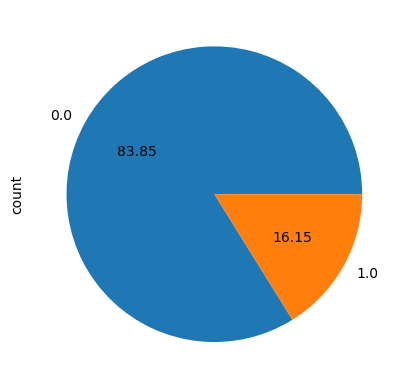

In [10]:
df['SR-ARE'].value_counts().plot.pie(autopct='%.2f')

In [11]:
df.isna().sum().sort_values(ascending=False)

SR-MMP           2021
NR-Aromatase     2010
SR-ARE           1999
NR-ER            1638
NR-PPAR-gamma    1381
SR-HSE           1364
NR-AhR           1282
NR-AR-LBD        1073
SR-p53           1057
NR-ER-LBD         876
SR-ATAD5          759
NR-AR             566
mol_id              0
smiles              0
dtype: int64

In [12]:
df_nr_ar = pd.DataFrame(columns=['NR-AR', 'smiles'], data=df[['NR-AR', 'smiles']].values)
df_sr_atad5 = pd.DataFrame(columns=['SR-ATAD5', 'smiles'], data=df[['SR-ATAD5', 'smiles']].values)
df_nr_er_lbd = pd.DataFrame(columns=['NR-ER-LBD', 'smiles'], data=df[['NR-ER-LBD', 'smiles']].values)

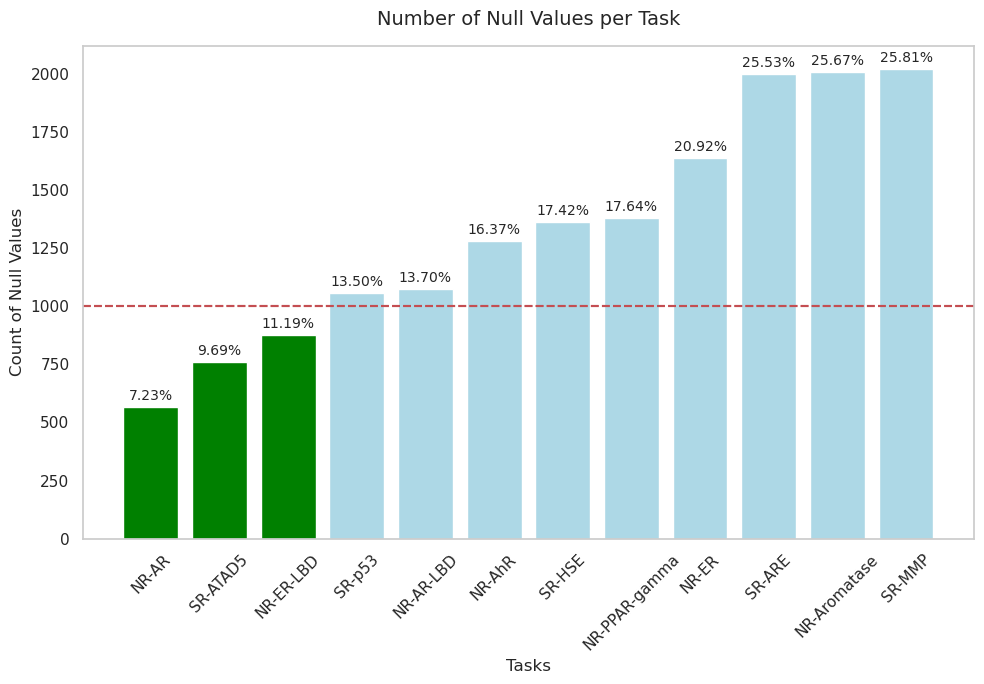

In [ ]:
# excluded mol_id and smiles
null_values =df.isna().sum().sort_values(ascending=True)[2:]
col_names =df.columns
import matplotlib.pyplot as plt
import seaborn as sns
# histogram of null values
plt.figure(figsize=(10,7))
sns.set_theme(style="whitegrid")
sns.barplot(x=null_values.index, y=null_values.values)
# twist the x-axis labels for better visibility
plt.xticks(rotation=90)

# color those less than 1000 in green
threshold = 1000
color  = ['green' if v < threshold else 'lightblue' for v in null_values.values]

fig_null_task = plt.bar(null_values.index, null_values.values, color=color)
plt.grid(False)
plt.axhline(y=threshold, color='r', linestyle='--') # horizontal line at threshold
# percentage of null values using mean
mean_nulls = null_values.mean()
total_rows = df.shape[0]
# percentage of null values on each bar
labels = [f'{v/total_rows*100:.2f}%' for v in null_values.values]
plt.gca().bar_label(fig_null_task, labels=labels, padding=3, fontsize=10)
plt.title('Number of Null Values per Task', fontsize=14, pad=15)
plt.ylabel('Count of Null Values')
plt.xlabel('Tasks')
plt.xticks(rotation=45)
plt.grid(False) # Ensures grid lines stay removed
plt.axhline(y=threshold, color='r', linestyle='--', label=f'Threshold ({threshold})')

plt.tight_layout()
plt.show()

In [14]:
df.head()

,NR-AR,NR-AR-LBD,NR-AhR,NR-Aromatase,NR-ER,NR-ER-LBD,NR-PPAR-gamma,SR-ARE,SR-ATAD5,SR-HSE,SR-MMP,SR-p53,mol_id,smiles
0,0.0,0.0,1.0,NaN,NaN,0.0,0.0,1.0,0.0,0.0,0.0,0.0,TOX3021,CCOc1ccc2nc(S(N)(=O)=O)sc2c1
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,0.0,NaN,0.0,0.0,TOX3020,CCN1C(=O)NC(c2ccccc2)C1=O
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,0.0,NaN,NaN,TOX3024,CC[C@]1(O)CC[C@H]2[C@@H]3CCC4=CCCC[C@@H]4[C@H]...
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,0.0,NaN,0.0,0.0,TOX3027,CCCN(CC)C(CC)C(=O)Nc1c(C)cccc1C
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,TOX20800,CC(O)(P(=O)(O)O)P(=O)(O)O


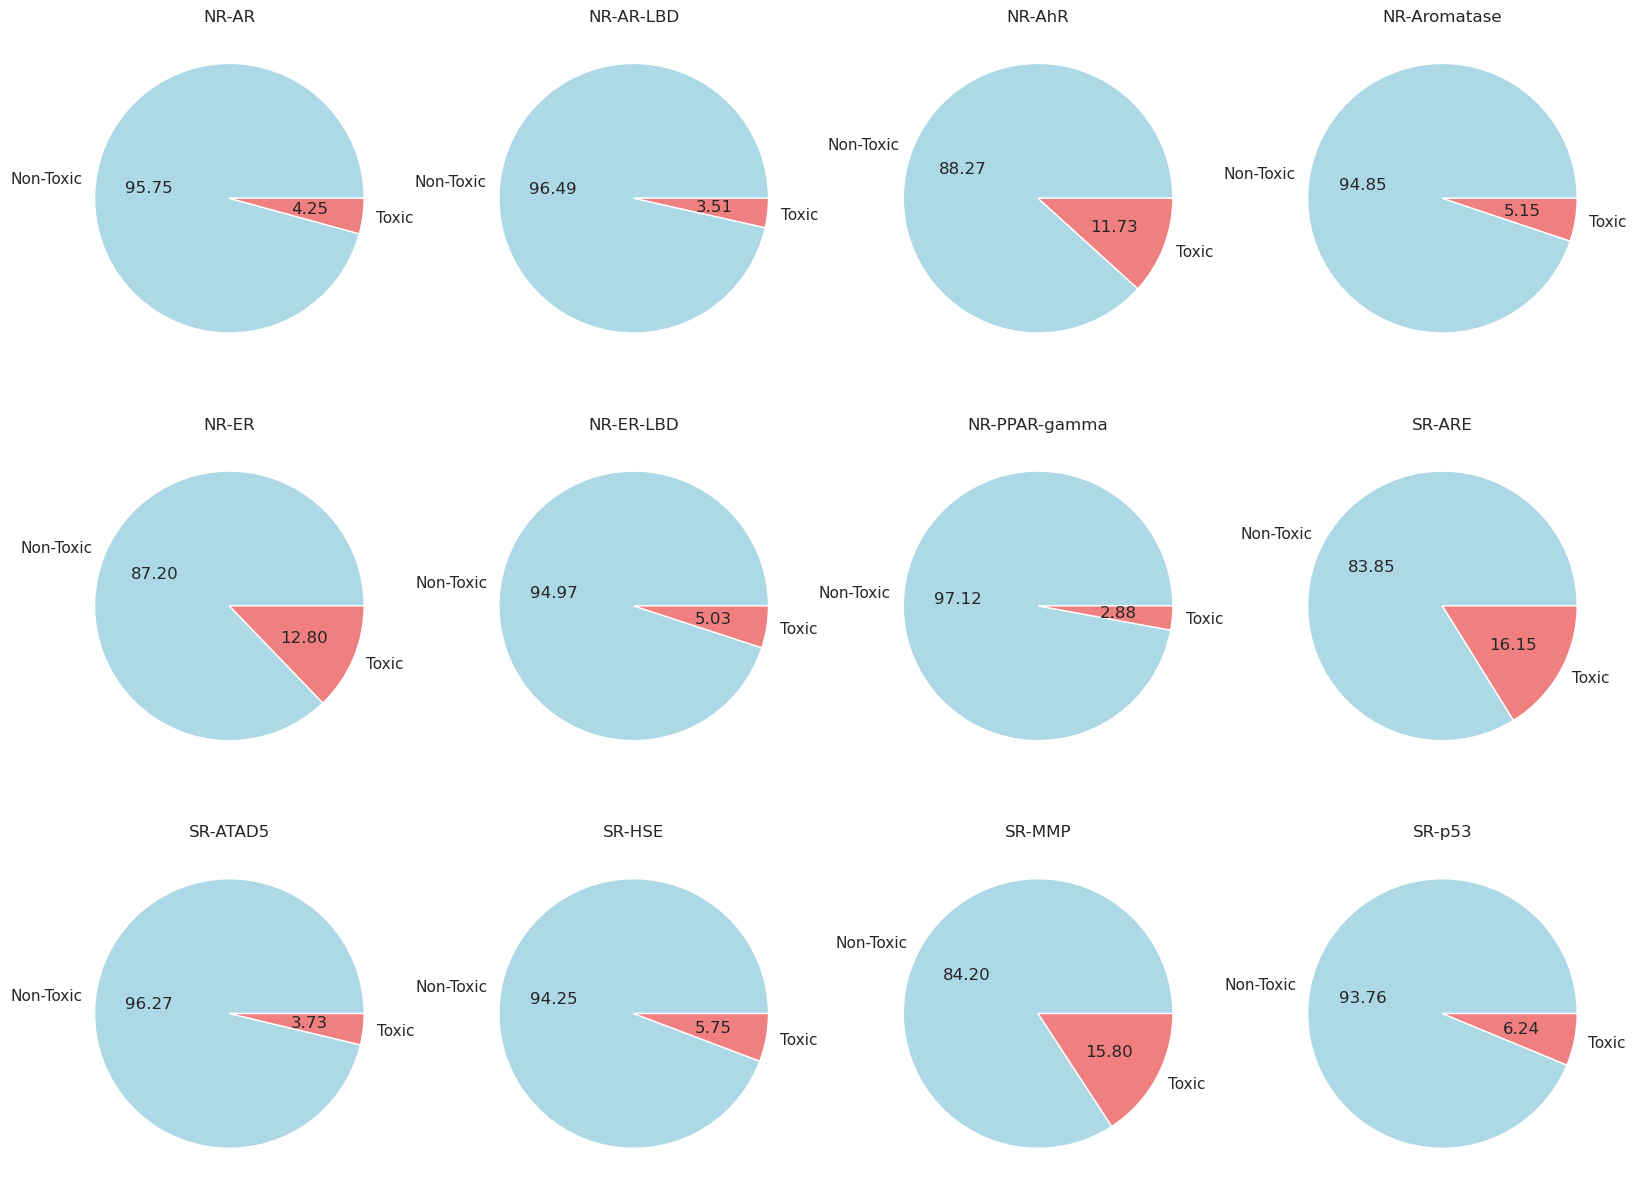

In [15]:
# visualizing the toxic compounds per Task (which are all except the mol_id and smiles columns)
task_columns = df.columns[:12]
value_counts = {task: df[task].value_counts() for task in task_columns}
# visualize the number of toxic compounds per task using a pie plot  per task
# and sort the value counts in descending order like above

plt.figure(figsize=(20, 15))
for i, task in enumerate(task_columns):
    plt.subplot(3, 4, i + 1)
    value_counts[task].plot.pie(autopct='%.2f', colors=['lightblue', 'lightcoral'], labels=['Non-Toxic', 'Toxic'])
    plt.title(task)
    plt.ylabel('')  # Remove y-label for clarity


<Figure size 1200x800 with 0 Axes>

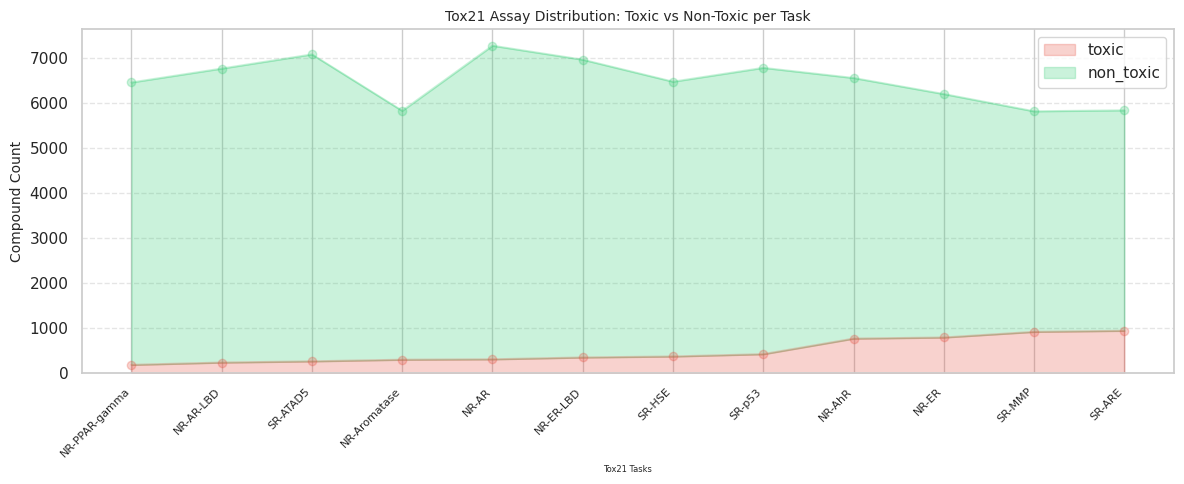

In [16]:
# create a filled bar version combining all in one figure
plt.figure(figsize=(12, 8))
# Count the number of toxic and non-toxic compounds for each task
toxic_df = pd.DataFrame({'toxic': (df[task_columns]==1).sum(),
                         'non_toxic': ((df[task_columns]==0).sum())})
toxic_df_sorted = toxic_df.sort_values(by = 'toxic')
# Plot Toxic vs Non-Toxic for each task side-by-side
colors={'toxic':'#e74c3c',"non_toxic": '#2ecc71'}
x = range(len(toxic_df_sorted))
ax = toxic_df_sorted.plot(kind='area', figsize=(12, 5),
                           color= [colors['toxic'], colors['non_toxic']], alpha = 0.25)
for line in ax.get_lines():
  line.set_marker('o')
ax.set_xticks(np.arange(len(toxic_df_sorted)))
ax.set_xticklabels(toxic_df_sorted.index, fontsize=8, rotation=45, ha='right')


plt.title('Tox21 Assay Distribution: Toxic vs Non-Toxic per Task', fontsize=10)
plt.ylabel('Compound Count', fontsize=10)
plt.xlabel('Tox21 Tasks', fontsize=6)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

In [17]:
import rdkit.Chem as Chem
from rdkit.Chem import MolFromSmiles
from  rdkit.Chem.Scaffolds import MurckoScaffold
import random
def get_scaffold(smiles:str)->str:
    """
    Given a SMILES string, return its Murcko scaffold as a SMILES string.
    """
    mol = MolFromSmiles(smiles)
    if not mol:
        return ""
    scaffold = MurckoScaffold.GetScaffoldForMol(mol)
    return Chem.MolToSmiles(scaffold)

def scaffold_split(smiles_list, train_frac=0.6, val_frac=0.2, seed=42):
    scaffold_idx_dict = defaultdict(list)
    for idx,smi in enumerate(smiles_list):
        scaffold = get_scaffold(smi)
        scaffold_idx_dict[scaffold].append(idx)
    scaffold_groups =list(scaffold_idx_dict.values())
    rng = random.Random(seed)
    rng.shuffle(scaffold_groups)

    n_total = len(smiles_list)
    train_cutoff = int(train_frac * n_total)
    val_cutoff   = int((train_frac + val_frac) * n_total)
    train_idx, val_idx, test_idx = [], [], []
    for group in scaffold_groups:
        if len(train_idx) < train_cutoff:
            train_idx.extend(group)
        elif len(train_idx) + len(val_idx) < val_cutoff:
            val_idx.extend(group)
        else:
            test_idx.extend(group)
    print(f"Scaffold split → train: {len(train_idx)}, "
          f"val: {len(val_idx)}, test: {len(test_idx)}")
    return train_idx, val_idx, test_idx, scaffold_idx_dict


In [19]:
from collections import defaultdict

train_idx, val_idx, test_idx, scaffold_idx_dict = scaffold_split(list(df["smiles"]))


[11:28:28] WARNING: not removing hydrogen atom without neighbors
[11:28:29] Explicit valence for atom # 8 Al, 6, is greater than permitted
[11:28:29] Explicit valence for atom # 3 Al, 6, is greater than permitted
[11:28:29] Explicit valence for atom # 4 Al, 6, is greater than permitted
[11:28:29] Explicit valence for atom # 4 Al, 6, is greater than permitted
[11:28:30] Explicit valence for atom # 9 Al, 6, is greater than permitted
[11:28:30] Explicit valence for atom # 5 Al, 6, is greater than permitted
[11:28:30] Explicit valence for atom # 16 Al, 6, is greater than permitted
[11:28:31] Explicit valence for atom # 20 Al, 6, is greater than permitted


Scaffold split → train: 4698, val: 2427, test: 706


In [20]:
index_to_scaffold = {
    idx: scaf 
    for scaf, indices in scaffold_idx_dict.items() 
    for idx in indices
}


In [21]:
df_scaffolds = df.drop(columns = 'mol_id').copy()
df_scaffolds['scaffolds'] = df_scaffolds.index.map(index_to_scaffold)
df_scaffolds.head()

,NR-AR,NR-AR-LBD,NR-AhR,NR-Aromatase,NR-ER,NR-ER-LBD,NR-PPAR-gamma,SR-ARE,SR-ATAD5,SR-HSE,SR-MMP,SR-p53,smiles,scaffolds
0,0.0,0.0,1.0,NaN,NaN,0.0,0.0,1.0,0.0,0.0,0.0,0.0,CCOc1ccc2nc(S(N)(=O)=O)sc2c1,c1ccc2scnc2c1
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,0.0,NaN,0.0,0.0,CCN1C(=O)NC(c2ccccc2)C1=O,O=C1NC(=O)C(c2ccccc2)N1
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,0.0,NaN,NaN,CC[C@]1(O)CC[C@H]2[C@@H]3CCC4=CCCC[C@@H]4[C@H]...,C1=C2CC[C@@H]3[C@H](CCC4CCC[C@H]43)[C@H]2CCC1
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,0.0,NaN,0.0,0.0,CCCN(CC)C(CC)C(=O)Nc1c(C)cccc1C,c1ccccc1
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,CC(O)(P(=O)(O)O)P(=O)(O)O,


In [22]:
def smiles_to_mol(smile:str):
    if isinstance(smile, str) and smile:
        return Chem.MolFromSmiles(smile)
    return None

In [23]:
df_mol_scaffold =df_scaffolds[['smiles', 'scaffolds']].copy()
df_mol_scaffold['mol_smiles'] = df_mol_scaffold['smiles'].apply(smiles_to_mol)
df_mol_scaffold['mol_scaffold'] = df_mol_scaffold['scaffolds'].apply(smiles_to_mol)

[11:28:33] WARNING: not removing hydrogen atom without neighbors
[11:28:34] Explicit valence for atom # 8 Al, 6, is greater than permitted
[11:28:34] Explicit valence for atom # 3 Al, 6, is greater than permitted
[11:28:34] Explicit valence for atom # 4 Al, 6, is greater than permitted
[11:28:34] Explicit valence for atom # 4 Al, 6, is greater than permitted
[11:28:34] Explicit valence for atom # 9 Al, 6, is greater than permitted
[11:28:34] Explicit valence for atom # 5 Al, 6, is greater than permitted
[11:28:34] Explicit valence for atom # 16 Al, 6, is greater than permitted
[11:28:35] Explicit valence for atom # 20 Al, 6, is greater than permitted


In [24]:
from rdkit.Chem.Draw import rdMolDraw2D
from IPython.display import HTML

def mol_to_svg(mol, width=200, height=150):
    """Converts RDKit Mol object to an inline HTML SVG string."""
    if mol is None:
        return ""
    drawer = rdMolDraw2D.MolDraw2DSVG(width, height)
    drawer.DrawMolecule(mol)
    drawer.FinishDrawing()
    return drawer.GetDrawingText()

In [25]:
df_mol_scaffold['img_smiles'] = df_mol_scaffold['mol_smiles'].apply(mol_to_svg)
df_mol_scaffold['img_scaffold'] = df_mol_scaffold['mol_scaffold'].apply(mol_to_svg)

In [26]:
HTML(df_mol_scaffold[['smiles', 'img_smiles', 'scaffolds', 'img_scaffold']].head().to_html(escape=False))

In [27]:
print(df_mol_scaffold['smiles'].nunique(), df_mol_scaffold['scaffolds'].nunique())

7831 2404


In [28]:
import random
from collections import defaultdict
from typing import Tuple, List, Union, Optional
from concurrent.futures import ProcessPoolExecutor

import numpy as np
import pandas as pd
from rdkit import Chem
from rdkit.Chem.Scaffolds import MurckoScaffold


def _smiles_to_scaffold(smi: str) -> str:
    """Helper for parallel execution: Convert single SMILES to Murcko Scaffold SMILES."""
    if not isinstance(smi, str) or not smi:
        return ""
    mol = Chem.MolFromSmiles(smi)
    if mol is None:
        return ""
    try:
        scaffold = MurckoScaffold.GetScaffoldForMol(mol)
        return Chem.MolToSmiles(scaffold)
    except Exception:
        return ""


def get_scaffolds_parallel(
    smiles_series: pd.Series, 
    n_jobs: int = -1
) -> pd.Series:
    """
    Computes Murcko scaffolds for a Pandas Series of SMILES using parallel processing.
    """
    import os
    if n_jobs == -1:
        n_jobs = max(1, os.cpu_count() - 1)

    smiles_list = smiles_series.tolist()
    
    if n_jobs > 1:
        with ProcessPoolExecutor(max_workers=n_jobs) as executor:
            scaffolds = list(executor.map(_smiles_to_scaffold, smiles_list, chunksize=500))
    else:
        scaffolds = [_smiles_to_scaffold(s) for s in smiles_list]

    return pd.Series(scaffolds, index=smiles_series.index, name="scaffold")


def scaffold_split(
    data: Union[pd.DataFrame, pd.Series, List[str]],
    smiles_col: Optional[str] = "smiles",
    train_frac: float = 0.8,
    val_frac: float = 0.1,
    test_frac: float = 0.1,
    seed: int = 42,
    n_jobs: int = -1,
    balanced: bool = True
) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
    """
    High-performance, Pythonic Bemis-Murcko scaffold splitter for pandas DataFrames/Series.

    Parameters
    ----------
    data : pd.DataFrame, pd.Series, or list
        Dataset containing SMILES strings.
    smiles_col : str, optional
        Name of column containing SMILES (if data is a DataFrame).
    train_frac : float
        Fraction of data for training.
    val_frac : float
        Fraction of data for validation.
    test_frac : float
        Fraction of data for testing.
    seed : int
        Random seed for shuffling equal-sized scaffold groups.
    n_jobs : int
        Number of CPU workers for parallel RDKit scaffold parsing (-1 uses all cores).
    balanced : bool
        If True, sorts scaffold clusters by size descending (Greedy Bin Packing), 
        ensuring optimal split sizes.

    Returns
    -------
    Tuple[np.ndarray, np.ndarray, np.ndarray]
        Arrays of train, validation, and test indices.
    """
    assert np.isclose(train_frac + val_frac + test_frac, 1.0), "Splits must sum to 1.0"

    # Extract Series of SMILES
    if isinstance(data, pd.DataFrame):
        smiles_series = data[smiles_col]
    elif isinstance(data, list):
        smiles_series = pd.Series(data)
    else:
        smiles_series = data

    # 1. Parallel computation of scaffolds
    scaffolds = get_scaffolds_parallel(smiles_series, n_jobs=n_jobs)

    # 2. Group indices by scaffold using Pandas groupby (C-speed grouping)
    scaffold_to_indices = defaultdict(list)
    for idx, scaf in zip(smiles_series.index, scaffolds):
        scaffold_to_indices[scaf].append(idx)

    # 3. Sort scaffold clusters
    # Sorting by cluster size descending (Greedy Bin Packing) guarantees better split ratios
    if balanced:
        # Sort by size descending, then shuffle groups of identical size deterministically
        rng = random.Random(seed)
        scaffold_groups = list(scaffold_to_indices.values())
        rng.shuffle(scaffold_groups)
        scaffold_groups.sort(key=len, reverse=True)
    else:
        scaffold_groups = list(scaffold_to_indices.values())
        rng = random.Random(seed)
        rng.shuffle(scaffold_groups)

    # 4. Greedy assignment to train / val / test sets
    n_total = len(smiles_series)
    train_cutoff = train_frac * n_total
    val_cutoff = (train_frac + val_frac) * n_total

    train_idx, val_idx, test_idx = [], [], []

    for group in scaffold_groups:
        if len(train_idx) + len(group) <= train_cutoff:
            train_idx.extend(group)
        elif len(train_idx) + len(val_idx) + len(group) <= val_cutoff:
            val_idx.extend(group)
        else:
            test_idx.extend(group)

    print(f"Scaffold Split Completed ({n_total} total compounds):")
    print(f"  Train : {len(train_idx):>6d} ({len(train_idx)/n_total:.2%})")
    print(f"  Val   : {len(val_idx):>6d} ({len(val_idx)/n_total:.2%})")
    print(f"  Test  : {len(test_idx):>6d} ({len(test_idx)/n_total:.2%})")

    return np.array(train_idx), np.array(val_idx), np.array(test_idx)